In [1]:
import torch
from torch.autograd import grad
from torch.optim.lr_scheduler import ReduceLROnPlateau
import sys
import datetime
sys.path.append('../..')
from src import train, utils
from src import calculus as calc
import src.data.cube_domain as cb
import src.models.mlp_model as mm
import src.models.expert_discontinuous as ed

In [2]:
from typing import Tuple
from math import pi

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TRAIN_TEMP_SAVE_PATH = './most_eff_model.pt'
RE = 1000
NU = 1 / RE
T_MAX = 1
L_BOUNDS = (0, 0, 0)
U_BOUNDS = (1, 1, 0.3)
L=1
W = 1.0
EULER=True

In [4]:
%load_ext autoreload
%autoreload 2

In [ ]:
from numpy import repeat


def g_N(x):
    return torch.column_stack((x[:, 0] * (1 - x[:, 0]) * x[:, 1] * (1 - torch.exp(-3 * x[:, 2])),
                               torch.zeros_like(x[:, 0:2])))
 
def f(x):
    y = (x[:, 0:1] * (x[:, 0:1] - 1) * x[:, 1:2] * (x[:, 1:2] - 1) * x[:, 2:3]).repeat(1, 2)
    return torch.column_stack((y, torch.ones_like(x[:, 0:1])))

In [ ]:
model_uv_ctx = mm.ModelContext(
    input_dim=3,
    output_dim=3,
    layer=[64, 64, 64, 64, 64],
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    hard_enforce=True,
    constraint_functions=(g_N, f)
)

model_p_ctx = mm.ModelContext(
    input_dim=3,
    output_dim=1,
    layer=[64, 64, 64, 64, 64],
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
)

model_expt_ctx = ed.DiscModelCtx(
    input_dim=3,
    output_dims=[2, 1],
    hidden_layers_per_output=[[32, 32, 32], [32, 32, 32]],
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    hard_enforce=True,
    constraint_functions=(g_N, f)
)


model_ept = ed.DiscontinousModel(model_expt_ctx).to(device)

print(model_ept.parameters())

optim_ept = torch.optim.Adam(model_ept.parameters(), lr=5e-3)
scheduler_ept = ReduceLROnPlateau(optim_ept, factor=0.5, patience=2_000)

model_uv = mm.MLPModel(model_uv_ctx).to(device)
model_p = mm.MLPModel(model_p_ctx).to(device)

optim_uv = torch.optim.Adam(model_uv.parameters(), lr=5e-4)
optim_p = torch.optim.Adam(model_p.parameters(), lr=5e-4)

# def init_weights(m):
#     if isinstance(m, torch.nn.Linear):
#         torch.nn.init.xavier_uniform_(m.weight, gain=torch.nn.init.calculate_gain('tanh'))
#         torch.nn.init.zeros_(m.bias)

# model_uv.apply(init_weights)
# model_p.load_state_dict(model_uv.state_dict())

<generator object Module.parameters at 0x7ccfcca66180>


In [7]:
# NOTE: input is assumed to have requires_grad=True
def pde_res(u: torch.Tensor, v:torch.Tensor, p: torch.Tensor, x: torch.Tensor):    
    u_grad = grad(u, x, torch.ones_like(u), create_graph=True)[0]
    v_grad = grad(v, x, torch.ones_like(v), create_graph=True)[0]
    u_x, u_y, u_t = u_grad[:, 0:1], u_grad[:, 1:2], u_grad[:, 2:3]
    v_x, v_y, v_t = v_grad[:, 0:1], v_grad[:, 1:2], u_grad[:, 2:3]
    
    u_xx = grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0][:, 0:1]
    u_yy = grad(u_y, x, torch.ones_like(u_y), create_graph=True)[0][:, 1:2]
    v_xx = grad(v_x, x, torch.ones_like(v_x), create_graph=True)[0][:, 0:1]
    v_yy = grad(v_y, x, torch.ones_like(v_y), create_graph=True)[0][:, 1:2]
    
    p_grad = grad(p, x, torch.ones_like(p), create_graph=True)[0]
    p_x, p_y = p_grad[:, 0:1], p_grad[:, 1:2]
    
    res_a = u_t + u * u_x + v * u_y + p_x - W * NU * (u_xx + u_yy)
    res_b = v_t + u * v_x + v * v_y + p_y - W * NU * (v_xx + v_yy)
    res_ct = u_x + v_y
        
    return res_a, res_b, res_ct

def euler_res(u: torch.Tensor, v:torch.Tensor, p: torch.Tensor, x: torch.Tensor):    
    u_grad = grad(u, x, torch.ones_like(u), create_graph=True)[0]
    v_grad = grad(v, x, torch.ones_like(v), create_graph=True)[0]
    u_x, u_y, u_t = u_grad[:, 0:1], u_grad[:, 1:2], u_grad[:, 2:3]
    v_x, v_y, v_t = v_grad[:, 0:1], v_grad[:, 1:2], u_grad[:, 2:3]
    
    p_grad = grad(p, x, torch.ones_like(p), create_graph=True)[0]
    p_x, p_y = p_grad[:, 0:1], p_grad[:, 1:2]
    
    res_a = u_t + u * u_x + v * u_y + p_x
    res_b = v_t + u * v_x + v * v_y + p_y
    res_ct = u_x + v_y
        
    return res_a, res_b, res_ct


def pde_loss_uv(model: torch.nn.Module, domain: cb.CubeDomain):
    pde_pts = domain.interior.clone().to(device).requires_grad_(True)
    uv_out = model(pde_pts)
    u, v = uv_out[:, 0:1], uv_out[:, 1:2]
    
    param_flags = [p.requires_grad for p in model_p.parameters()]
    for par in model_p.parameters():
        par.requires_grad = False
    
    p = model_p(pde_pts)[:, 0:1]

    for par, flag in zip(model_p.parameters(), param_flags):
        par.requires_grad = flag

    if EULER:
        pde_res_a, pde_res_b, pde_res_ct  = euler_res(u, v, p, pde_pts)
    else:
        pde_res_a, pde_res_b, pde_res_ct  = pde_res(u, v, p, pde_pts)

    return [10 * torch.mean(pde_res_a**2 + pde_res_b**2), torch.mean(pde_res_ct**2)]


def pde_loss_p(model: torch.nn.Module, domain: cb.CubeDomain):
    pde_pts = domain.interior.clone().to(device).requires_grad_(True)
    
    param_flags = [p.requires_grad for p in model_uv.parameters()]
    
    for par in model_uv.parameters():
        par.requires_grad = False
    
    uv_out = model_uv(pde_pts)
    u, v = uv_out[:, 0:1], uv_out[:, 1:2]
    
    for par, flag in zip(model_uv.parameters(), param_flags):
        par.requires_grad = flag
    
    p = model(pde_pts)[:, 0:1]

    if EULER:
        pde_res_a, pde_res_b, _  = euler_res(u, v, p, pde_pts)
    else:
        pde_res_a, pde_res_b, _  = pde_res(u, v, p, pde_pts)
    
    return [torch.mean(pde_res_a**2 + pde_res_b**2)]


def pde_loss_uvp(model: torch.nn.Module, domain: cb.CubeDomain):
    pde_pts = domain.interior.clone().to(device).requires_grad_(True)
    model_out = model(pde_pts)
    u, v, p = model_out[:, 0:1], model_out[:, 1:2], model_out[:, 2:3]

    if EULER:
        pde_res_a, pde_res_b, pde_res_ct  = euler_res(u, v, p, pde_pts)
    else:
        pde_res_a, pde_res_b, pde_res_ct  = pde_res(u, v, p, pde_pts)
        
    res = pde_res_a**2 + pde_res_b**2 + pde_res_ct**2
    res_grad = torch.max(torch.norm(grad(res, pde_pts, torch.ones_like(res), create_graph=True)[0][:, 0:2], dim=1))

    return [5*torch.mean(pde_res_a**2 + pde_res_b**2), torch.mean(pde_res_ct**2), 0.01 * res_grad]

In [8]:
domain_ctx = cb.CubeContext(
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    dim=3,
    device=device,
    int_sampling='Latin', 
    N_int=10_000,
    N_sides=[(0, 0), (0, 0), (0, 0)],
)

domain = cb.CubeDomain(domain_ctx)

In [9]:
# define plot context
plot_ctx = utils.PlotContext(
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    function_names = ['u'],
    titles= ['Model prediction (velocity)'],
    device=device,
    vmin=0,
    vmax=2,
    patches=[],
    N = 100
)

In [10]:
train_uv_ctx = train.TrainingContext(
    model=model_ept,
    optimizer=optim_ept,
    domain=domain,
    loss_fn=pde_loss_uvp,
    resample=True,
    epochs=60_000,
    monitor_gradient=True,
    monitor_lr=True,
    scheduler=scheduler_ept
)

train_p_ctx = train.TrainingContext(
    model=model_p,
    optimizer=optim_p,
    domain=domain,
    loss_fn=pde_loss_p,
    resample=True,
    epochs=200,
    monitor_gradient=True,
    monitor_lr=True
)

CYCLES_EULER = 400
CYCLES_PER_WEIGHT = 1
EULER = False

cont_only_loss, cont_only_loss_comp = train.train_switch_to_lbfgs(train_uv_ctx, lbfgs_lr=1)

losses_uv = [[], [[], [], []]]
losses_omega = [[], [[], [], []]]

print(f"PRE-TRAINING ON EULER\n\n")

# for cycle in range(CYCLES_EULER):
#     if cycle % 10 == 0:
#         plot_ctx.titles = [f'Model prediction at epoch {cycle * 400}'] 
#         utils.plot_vector_field_2d([velocity], plot_ctx, N=25, n_heigth=25, n_width=25)
    
#     print(f"Starting cycle {cycle+1}/{CYCLES_EULER}")
#     print("Holding p-model const; training uv-model...")
    
#     model_p.eval()
#     model_uv.train()
#     uv_total_loss, uv_comp_loss = train.simple_train(train_uv_ctx)
#     losses_uv[0] += uv_total_loss
    
#     for i, comp_loss in enumerate(uv_comp_loss):
#         losses_uv[1][i] += comp_loss
    
#     print("Holding uv-model const; training p-model...")
    
#     model_p.train()
#     model_uv.eval()
#     p_total_loss, p_comp_loss = train.simple_train(train_p_ctx)
#     losses_omega[0] += p_total_loss
    
#     for i, comp_loss in enumerate(p_comp_loss):
#         losses_omega[1][i] += comp_loss
        
#     if cycle == 200:
#         train_uv_ctx.optimizer = torch.optim.Adam(model_uv.parameters(), lr=1e-4)
#         train_p_ctx.optimizer = torch.optim.Adam(model_p.parameters(), lr=1e-4)


# print("\n\nSTARTING CURRICULUM\n\n")

# weights = [0.1, 0.5, 1.0]
# train_uv_ctx.optimizer = torch.optim.Adam(model_uv.parameters(), lr=5e-5)
# train_p_ctx.optimizer = torch.optim.Adam(model_p.parameters(), lr=5e-5)
# EULER = False

# for W in weights:
#     for cycle in range(CYCLES_PER_WEIGHT):
#         print(f"Starting cycle {cycle+1}/{CYCLES_PER_WEIGHT}")
#         print("Holding p-model const; training uv-model...")
        
#         model_p.eval()
#         model_uv.train()
#         uv_total_loss, uv_comp_loss = train.simple_train(train_uv_ctx)
#         losses_uv[0] += uv_total_loss
        
#         for i, comp_loss in enumerate(uv_comp_loss):
#             losses_uv[1][i] += comp_loss
        
#         print("Holding uv-model const; training p-model...")
        
#         model_p.train()
#         model_uv.eval()
#         p_total_loss, p_comp_loss = train.simple_train(train_p_ctx)
#         losses_omega[0] += p_total_loss
        
#         for i, comp_loss in enumerate(p_comp_loss):
#             losses_omega[1][i] += comp_loss


Loss at epoch 1 is: 0.40527430176734924. Total gradient norm: 1.0223187753595007 Current learing rate: 0.005 
Loss at epoch 100 is: 0.06054428592324257. Total gradient norm: 0.21471582622765717 Current learing rate: 0.005 
Loss at epoch 200 is: 0.05233577638864517. Total gradient norm: 0.13054398943455334 Current learing rate: 0.005 
Loss at epoch 300 is: 0.04695911332964897. Total gradient norm: 0.04927457828411198 Current learing rate: 0.005 
Loss at epoch 400 is: 0.04439956322312355. Total gradient norm: 0.31970337290025613 Current learing rate: 0.005 
Loss at epoch 500 is: 0.042705606669187546. Total gradient norm: 0.24776903246444076 Current learing rate: 0.005 
Loss at epoch 600 is: 0.04256480187177658. Total gradient norm: 0.10793071699596257 Current learing rate: 0.005 
Loss at epoch 700 is: 0.042100079357624054. Total gradient norm: 0.0891453041444433 Current learing rate: 0.005 
Loss at epoch 800 is: 0.04082981124520302. Total gradient norm: 0.0980192606937115 Current learing

/home/berva/miniconda3/envs/torch/lib/python3.12/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /opt/conda/conda-bld/libtorch_1745854776362/work/aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
/home/berva/miniconda3/envs/torch/lib/python3.12/site-packages/matplotlib/quiver.py:676: RuntimeWarning: Mean of empty slice.
  amean = a[~self.Umask].mean()
/home/berva/miniconda3/envs/torch/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


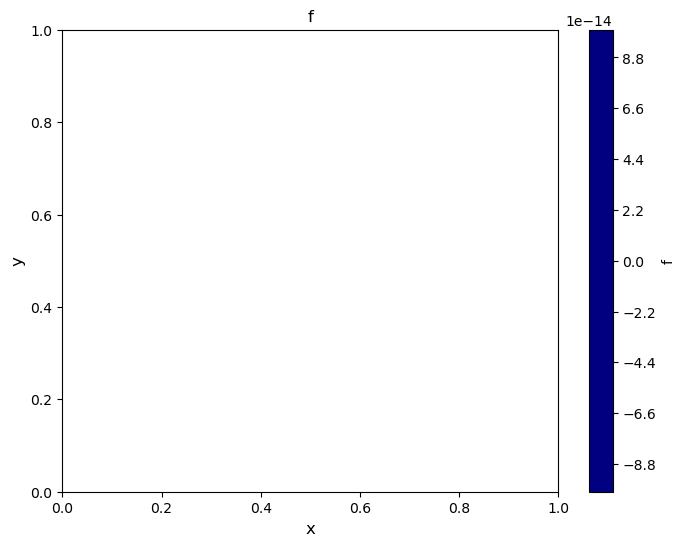

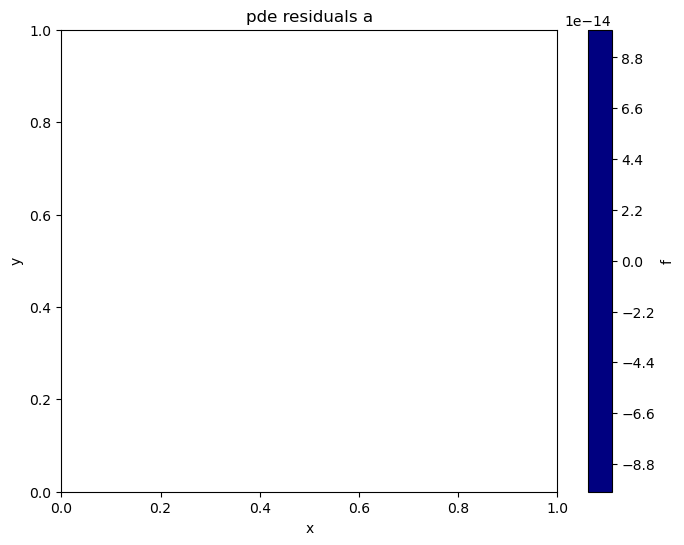

/home/berva/Projects2/Projects/PINNs/Introduction/notebooks/nav_stokes/../../src/utils.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_x_labels)


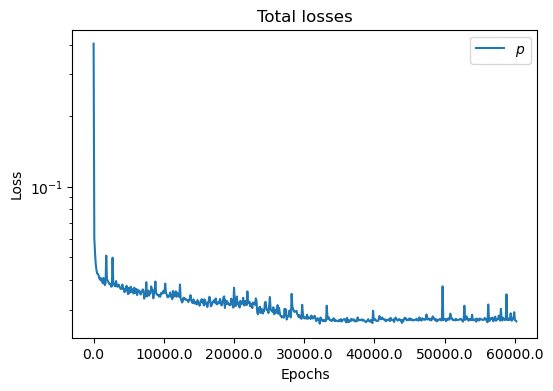

/home/berva/Projects2/Projects/PINNs/Introduction/notebooks/nav_stokes/../../src/utils.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_x_labels)


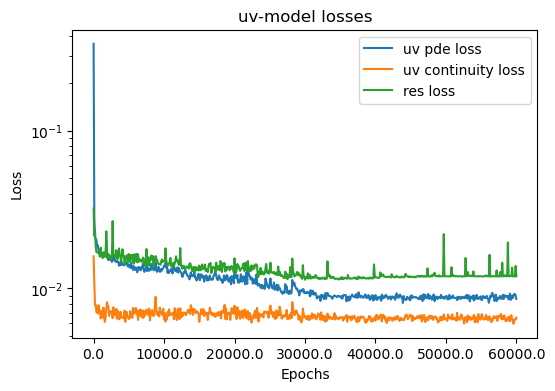

In [11]:
plot_ctx.vmin=0
plot_ctx.vmax=0.6
plot_ctx.titles = ['f', 'g_N']
plot_ctx.function_names = ['f', 'g_N']
plot_ctx.figsize=(8, 6)

def velocity(x: torch.Tensor) -> torch.Tensor:
    x = torch.column_stack((x, torch.full_like(x[:, 0], 0.3))).requires_grad_(True)
    
    return model_ept(x)[:, 0:2]

utils.plot_vector_field_2d([velocity], plot_ctx, N=25, n_heigth=30, n_width=30)

#utils.plot_function_on_2d_cube([f, g_N], plot_ctx)

#utils.plot_function_on_2d_cube([lambda x: model(x)[:, 0]], plot_ctx)

def res_helper(x):
    x = torch.column_stack((x, torch.full_like(x[:, 0], 0.3))).requires_grad_(True)

    uvp = model_ept(x)
    
    u, v, p = uvp[:, 0:1], uvp[:, 1:2], uvp[:, 2:3]
    
    res_a, res_b, res_ct = pde_res(u, v, p, x)
        
    res = res_a**2 + res_b**2 + res_ct**2
    res_grad = grad(res, x, torch.ones_like(res))[0][:, 0:2]
    
        
    return torch.clamp(torch.abs(res), 0.0, 0.1)
    return torch.clamp(torch.norm(res_grad, dim=1), 0.0, 10.0)


plot_ctx.titles = ['pde residuals a']
plot_ctx.vmax = 0.1
utils.plot_function_on_2d_cube([res_helper], plot_ctx)


plot_ctx.x_label = "Epochs"
plot_ctx.y_label = "Loss"

plot_ctx.titles = ["Total losses"]
utils.plot_loss_values({r"$p$": cont_only_loss}, plot_ctx)

plot_ctx.titles = ["uv-model losses"]
utils.plot_loss_values({r"uv pde loss": cont_only_loss_comp[0], r"uv continuity loss": cont_only_loss_comp[1], r"res loss": cont_only_loss_comp[2]}, plot_ctx)